<a href="https://colab.research.google.com/github/rodrigorissettoterra/ai-model-studies/blob/main/009_rag_question_answering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Construindo e avaliando um sistema de perguntas e respostas com recuperação de contexto

**Área:** Generative AI  
**Tipo de problema:** Retrieval-Augmented Question Answering

### Pergunta de estudo

> Adicionar recuperação semântica melhora a capacidade de um LLM responder perguntas factuais quando comparado ao mesmo modelo sem acesso ao contexto?

### Pipeline

```text
Documentos → Chunking → Embeddings → FAISS
                              ↓
Pergunta → Query embedding → Top-K
                              ↓
                          Contexto
                              ↓
                             LLM
                              ↓
                       Resposta + fontes
```

### Componentes

- **Dataset:** SQuAD 1.1
- **Embeddings:** `sentence-transformers/all-MiniLM-L6-v2`
- **Vector store:** FAISS
- **LLM:** `Qwen/Qwen2.5-1.5B-Instruct`

### Avaliação

**Retrieval**
- Hit@1
- Hit@K
- MRR

**Generation**
- Exact Match
- Token F1
- Answer Containment

O objetivo é observar o RAG como um **sistema composto**, no qual retrieval e generation podem falhar independentemente.


## 1. Configuração do ambiente

O notebook foi projetado para Google Colab. A etapa de geração é muito mais rápida com GPU.


In [1]:
!pip -q install -U datasets sentence-transformers faiss-cpu transformers accelerate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.3/611.3 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 12.2 MB/s eta 0:00:00


In [2]:
import random
import re
import string
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import faiss

from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

CORPUS_CONTEXTS = 300
CHUNK_SIZE_WORDS = 120
CHUNK_OVERLAP_WORDS = 30
TOP_K = 4
RETRIEVAL_EVAL_K = 10
RETRIEVAL_EVAL_QUESTIONS = 100
GENERATION_EVAL_QUESTIONS = 15

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
GENERATION_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

print("GPU disponível:", torch.cuda.is_available())


GPU disponível: True


## 2. Dataset — SQuAD

O SQuAD fornece textos, perguntas e respostas de referência.  
Para cada pergunta, o contexto original funciona como documento relevante conhecido, permitindo avaliar retrieval de forma objetiva.


In [3]:
squad = load_dataset("rajpurkar/squad", split="validation")
raw_df = squad.to_pandas()

contexts_df = (
    raw_df[["title", "context"]]
    .drop_duplicates("context")
    .sample(
        n=min(CORPUS_CONTEXTS, raw_df["context"].nunique()),
        random_state=SEED,
    )
    .reset_index(drop=True)
)

contexts_df["source_id"] = [f"doc_{i:04d}" for i in range(len(contexts_df))]

qa_pool = raw_df.merge(
    contexts_df[["context", "source_id"]],
    on="context",
    how="inner",
)

qa_pool["reference_answer"] = qa_pool["answers"].apply(
    lambda x: x["text"][0]
)

print("Documentos:", len(contexts_df))
print("Perguntas disponíveis:", len(qa_pool))
display(qa_pool[["source_id","title","question","reference_answer"]].head())


README.md:   0%|          | 0.00/7.62k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 14.5MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/validation-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B / 1.82MB            

plain_text/validation-00000-of-00001.par(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

Documentos: 300
Perguntas disponíveis: 1502


,source_id,title,question,reference_answer
0,doc_0248,Super_Bowl_50,At what university's facility did the Panthers...,San Jose State
1,doc_0248,Super_Bowl_50,At what university's facility did the Broncos ...,Stanford University
2,doc_0248,Super_Bowl_50,In what city's Marriott did the Panthers stay?,San Jose
3,doc_0248,Super_Bowl_50,In what city's Marriott did the Broncos stay?,Santa Clara
4,doc_0248,Super_Bowl_50,What hotel did the Panthers stay in during Sup...,San Jose Marriott


## 3. Chunking

Os documentos são divididos em janelas de palavras com overlap. Cada chunk preserva sua origem (`source_id`).


In [4]:
def split_into_chunks(text, chunk_size=120, overlap=30):
    words = str(text).split()
    if chunk_size <= overlap:
        raise ValueError("chunk_size deve ser maior que overlap")

    chunks, start = [], 0
    while start < len(words):
        end = min(start + chunk_size, len(words))
        chunks.append(" ".join(words[start:end]))
        if end == len(words):
            break
        start = end - overlap
    return chunks

rows = []
for _, row in contexts_df.iterrows():
    for i, chunk in enumerate(
        split_into_chunks(row["context"], CHUNK_SIZE_WORDS, CHUNK_OVERLAP_WORDS)
    ):
        rows.append({
            "source_id": row["source_id"],
            "title": row["title"],
            "chunk_index": i,
            "text": chunk,
        })

chunks_df = pd.DataFrame(rows)
chunks_df["chunk_id"] = [f"chunk_{i:05d}" for i in range(len(chunks_df))]

print("Chunks:", len(chunks_df))
print("Média de chunks/documento:", round(len(chunks_df)/len(contexts_df), 2))
display(chunks_df.head())


Chunks: 443
Média de chunks/documento: 1.48


,source_id,title,chunk_index,text,chunk_id
0,doc_0000,Nikola_Tesla,0,"Near the end of his life, Tesla walked to the ...",chunk_00000
1,doc_0001,Huguenot,0,"The pattern of warfare, followed by brief peri...",chunk_00001
2,doc_0002,Private_school,0,"Legally, only non-profit trusts and societies ...",chunk_00002
3,doc_0002,Private_school,1,government schools and an increasing number of...,chunk_00003
4,doc_0003,Nikola_Tesla,0,"On his 50th birthday in 1906, Tesla demonstrat...",chunk_00004


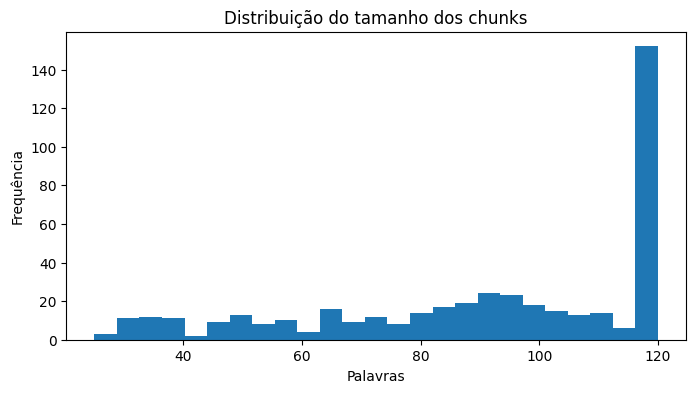

In [5]:
chunk_lengths = chunks_df["text"].str.split().str.len()

plt.figure(figsize=(8,4))
plt.hist(chunk_lengths, bins=25)
plt.title("Distribuição do tamanho dos chunks")
plt.xlabel("Palavras")
plt.ylabel("Frequência")
plt.show()


## 4. Embeddings

Os embeddings são normalizados. Em busca assimétrica, usamos `encode_document` e `encode_query` quando disponíveis.


In [6]:
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

if hasattr(embedding_model, "encode_document"):
    corpus_embeddings = embedding_model.encode_document(
        chunks_df["text"].tolist(),
        normalize_embeddings=True,
        show_progress_bar=True,
    )
else:
    corpus_embeddings = embedding_model.encode(
        chunks_df["text"].tolist(),
        normalize_embeddings=True,
        show_progress_bar=True,
    )

corpus_embeddings = np.asarray(corpus_embeddings, dtype="float32")
print("Embeddings:", corpus_embeddings.shape)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Embeddings: (443, 384)


## 5. Índice vetorial FAISS

Com vetores normalizados, `IndexFlatIP` pode ser usado como busca exata por similaridade de cosseno.


In [7]:
dimension = corpus_embeddings.shape[1]
vector_index = faiss.IndexFlatIP(dimension)
vector_index.add(corpus_embeddings)

print("Vetores indexados:", vector_index.ntotal)


Vetores indexados: 443


## 6. Retriever


In [8]:
def encode_query(query):
    if hasattr(embedding_model, "encode_query"):
        emb = embedding_model.encode_query([query], normalize_embeddings=True)
    else:
        emb = embedding_model.encode([query], normalize_embeddings=True)
    return np.asarray(emb, dtype="float32")

def retrieve(query, top_k=TOP_K):
    scores, indices = vector_index.search(encode_query(query), top_k)
    results = []

    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        row = chunks_df.iloc[int(idx)]
        results.append({
            "rank": rank,
            "score": float(score),
            "chunk_id": row["chunk_id"],
            "source_id": row["source_id"],
            "title": row["title"],
            "text": row["text"],
        })

    return pd.DataFrame(results)

example = qa_pool.iloc[0]
print("Pergunta:", example["question"])
print("Fonte esperada:", example["source_id"])
display(retrieve(example["question"]))


Pergunta: At what university's facility did the Panthers practice?
Fonte esperada: doc_0248


,rank,score,chunk_id,source_id,title,text
0,1,0.731255,chunk_00361,doc_0248,Super_Bowl_50,The Panthers used the San Jose State practice ...
1,2,0.407699,chunk_00371,doc_0256,Super_Bowl_50,The Panthers seemed primed to score on their o...
2,3,0.352122,chunk_00389,doc_0268,University_of_Chicago,"In the 1890s, the University of Chicago, fearf..."
3,4,0.305939,chunk_00249,doc_0172,University_of_Chicago,"by Edward Durrell Stone, and the Regenstein Li..."


## 7. Avaliação do retrieval

**Hit@K** verifica se o documento correto aparece nos K primeiros resultados.  
**MRR** valoriza sistemas que colocam o primeiro documento relevante nas primeiras posições.


In [9]:
retrieval_eval_df = qa_pool.sample(
    n=min(RETRIEVAL_EVAL_QUESTIONS, len(qa_pool)),
    random_state=SEED,
).reset_index(drop=True)

records = []
start = time.perf_counter()

for _, row in retrieval_eval_df.iterrows():
    result = retrieve(row["question"], RETRIEVAL_EVAL_K)
    sources = result["source_id"].tolist()

    positions = [
        rank for rank, source in enumerate(sources, start=1)
        if source == row["source_id"]
    ]

    first_rank = positions[0] if positions else None

    records.append({
        "question": row["question"],
        "gold_source": row["source_id"],
        "hit@1": int(row["source_id"] in sources[:1]),
        f"hit@{TOP_K}": int(row["source_id"] in sources[:TOP_K]),
        f"hit@{RETRIEVAL_EVAL_K}": int(row["source_id"] in sources[:RETRIEVAL_EVAL_K]),
        "reciprocal_rank": 1/first_rank if first_rank else 0.0,
    })

retrieval_results = pd.DataFrame(records)
elapsed = time.perf_counter() - start

retrieval_summary = pd.Series({
    "Hit@1": retrieval_results["hit@1"].mean(),
    f"Hit@{TOP_K}": retrieval_results[f"hit@{TOP_K}"].mean(),
    f"Hit@{RETRIEVAL_EVAL_K}": retrieval_results[f"hit@{RETRIEVAL_EVAL_K}"].mean(),
    "MRR": retrieval_results["reciprocal_rank"].mean(),
    "Tempo médio/query (ms)": elapsed / len(retrieval_results) * 1000,
})

display(retrieval_summary.to_frame("Resultado").round(4))


,Resultado
Hit@1,0.8100
Hit@4,0.9500
Hit@10,0.9900
MRR,0.8782
Tempo médio/query (ms),18.8476


## 8. LLM

O mesmo modelo será usado nos dois cenários:

```text
Pergunta → LLM
```

versus

```text
Pergunta → Retrieval → Contexto → LLM
```

Assim, a principal variável entre os experimentos é a presença do contexto recuperado.


In [10]:
tokenizer = AutoTokenizer.from_pretrained(GENERATION_MODEL_NAME)

generation_model = AutoModelForCausalLM.from_pretrained(
    GENERATION_MODEL_NAME,
    dtype="auto",
    device_map="auto",
)

print("Modelo:", GENERATION_MODEL_NAME)
print(
    "Memória aproximada (GB):",
    round(generation_model.get_memory_footprint()/1024**3, 2),
)


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Modelo: Qwen/Qwen2.5-1.5B-Instruct
Memória aproximada (GB): 2.88


In [11]:
def generate_response(messages, max_new_tokens=100):
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(generation_model.device)

    with torch.inference_mode():
        generated = generation_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    new_tokens = generated[:, inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens[0], skip_special_tokens=True).strip()


## 9. Baseline — LLM sem RAG


In [12]:
def answer_without_rag(question):
    return generate_response([
        {
            "role": "system",
            "content": (
                "Answer factual questions concisely. "
                "If you do not know, say 'I don't know'. "
                "Return only the answer."
            ),
        },
        {"role": "user", "content": question},
    ], max_new_tokens=60)

baseline_example = answer_without_rag(example["question"])
print("Resposta sem RAG:", baseline_example)


Resposta sem RAG: North Carolina State University


## 10. RAG — contexto + geração

O modelo é instruído a usar apenas os chunks recuperados e informar as fontes.


In [13]:
def build_context(retrieved):
    blocks = []
    for _, row in retrieved.iterrows():
        blocks.append(
            f"[SOURCE: {row['source_id']} | TITLE: {row['title']}]\n{row['text']}"
        )
    return "\n\n".join(blocks)

def answer_with_rag(question, top_k=TOP_K):
    retrieved = retrieve(question, top_k)
    context = build_context(retrieved)

    response = generate_response([
        {
            "role": "system",
            "content": (
                "Answer using only the provided context. "
                "If the context does not support the answer, say "
                "'I don't know based on the provided context.' "
                "Use exactly this format:\n"
                "ANSWER: <short answer>\n"
                "SOURCES: <source ids used>"
            ),
        },
        {
            "role": "user",
            "content": f"QUESTION:\n{question}\n\nCONTEXT:\n{context}",
        },
    ], max_new_tokens=100)

    return response, retrieved, context

rag_example, rag_example_retrieved, _ = answer_with_rag(example["question"])

print(rag_example)
display(rag_example_retrieved[["rank","score","source_id","title"]])


ANSWER: I don't know based on the provided context.
SOURCES: doc_0248, doc_0256, doc_0268, doc_0172


,rank,score,source_id,title
0,1,0.731255,doc_0248,Super_Bowl_50
1,2,0.407699,doc_0256,Super_Bowl_50
2,3,0.352122,doc_0268,University_of_Chicago
3,4,0.305939,doc_0172,University_of_Chicago


## 11. Métricas de geração

As métricas clássicas do SQuAD serão aplicadas à parte `ANSWER` da resposta.


In [14]:
def normalize_answer(text):
    text = str(text).lower()
    text = "".join(c for c in text if c not in string.punctuation)
    text = re.sub(r"\b(a|an|the)\b", " ", text)
    return " ".join(text.split())

def exact_match(prediction, reference):
    return int(normalize_answer(prediction) == normalize_answer(reference))

def token_f1(prediction, reference):
    p = normalize_answer(prediction).split()
    r = normalize_answer(reference).split()
    if not p or not r:
        return 0.0

    common = Counter(p) & Counter(r)
    same = sum(common.values())
    if same == 0:
        return 0.0

    precision = same / len(p)
    recall = same / len(r)
    return 2 * precision * recall / (precision + recall)

def best_over_references(prediction, references, metric):
    return max(metric(prediction, ref) for ref in references)

def containment(prediction, references):
    p = normalize_answer(prediction)
    return int(any(normalize_answer(ref) in p for ref in references if ref))

def parse_rag_response(response):
    answer_match = re.search(
        r"ANSWER:\s*(.*?)(?:\nSOURCES:|$)",
        response,
        flags=re.I | re.S,
    )
    sources_match = re.search(r"SOURCES:\s*(.*)$", response, flags=re.I | re.S)

    answer = answer_match.group(1).strip() if answer_match else response.strip()
    sources = sources_match.group(1).strip() if sources_match else ""
    return answer, sources


## 12. Comparação: sem RAG vs RAG

Por padrão, a geração usa uma amostra menor porque é a etapa computacionalmente mais cara.


In [15]:
generation_eval_df = qa_pool.sample(
    n=min(GENERATION_EVAL_QUESTIONS, len(qa_pool)),
    random_state=SEED + 1,
).reset_index(drop=True)

rows = []

for i, row in generation_eval_df.iterrows():
    question = row["question"]
    references = row["answers"]["text"]
    gold_source = row["source_id"]

    print(f"[{i+1}/{len(generation_eval_df)}] {question[:70]}")

    t0 = time.perf_counter()
    baseline_answer = answer_without_rag(question)
    baseline_latency = time.perf_counter() - t0

    t0 = time.perf_counter()
    rag_raw, retrieved, context = answer_with_rag(question)
    rag_latency = time.perf_counter() - t0

    rag_answer, rag_sources = parse_rag_response(rag_raw)
    retrieved_sources = retrieved["source_id"].tolist()

    rows.append({
        "question": question,
        "gold_source": gold_source,
        "reference_answer": references[0],

        "baseline_answer": baseline_answer,
        "baseline_em": best_over_references(baseline_answer, references, exact_match),
        "baseline_f1": best_over_references(baseline_answer, references, token_f1),
        "baseline_containment": containment(baseline_answer, references),
        "baseline_latency_s": baseline_latency,

        "rag_answer": rag_answer,
        "rag_sources": rag_sources,
        "retrieval_hit": int(gold_source in retrieved_sources),
        "answer_supported": containment(context, references),
        "rag_em": best_over_references(rag_answer, references, exact_match),
        "rag_f1": best_over_references(rag_answer, references, token_f1),
        "rag_containment": containment(rag_answer, references),
        "rag_latency_s": rag_latency,
    })

generation_results = pd.DataFrame(rows)

display(
    generation_results[
        ["question","reference_answer","baseline_answer","rag_answer",
         "retrieval_hit","answer_supported","baseline_f1","rag_f1"]
    ]
)


[1/15] What shape are pyrenoids?
[2/15] Who made experimental measurements on a model steam engine?
[3/15] What do some believe the Treaty of Versailles assisted in?
[4/15] What was the Disneyland anthology series retitled in 1958?
[5/15] How many universities does Newcastle have?
[6/15] What was the largest pottery company in the world in 1817?
[7/15] What is the term of office for each house member?
[8/15] Who was assigned to design a second master plan?
[9/15] What is another term for the pivot mounting?
[10/15] Who invited Washington to dine with him?
[11/15] When did the KMJ-TV first broadcast?
[12/15] Who painted the retable of St. George that is in the V&A collection?
[13/15] When does Doctor Who transition to a new body?
[14/15] How is packet mode communication implemented 
[15/15] What animals does the Vistula river's ecosystem include?


,question,reference_answer,baseline_answer,rag_answer,retrieval_hit,answer_supported,baseline_f1,rag_f1
0,What shape are pyrenoids?,roughly spherical,pyrenoids are spherical in shape.,Roughly spherical,1,1,0.333333,1.000000
1,Who made experimental measurements on a model ...,Watt,James Watt,Watt,1,1,0.666667,1.000000
2,What do some believe the Treaty of Versailles ...,Adolf Hitler's rise to power,Some believe that the Treaty of Versailles ass...,The Treaty of Versailles and the prohibition o...,1,1,0.095238,0.357143
3,What was the Disneyland anthology series retit...,Walt Disney Presents,"The Disneyland anthology series was retitled ""...",Walt Disney Presents,1,1,0.000000,1.000000
4,How many universities does Newcastle have?,two,Newcastle has two main universities: Newcastle...,Two universities,1,1,0.181818,0.666667
5,What was the largest pottery company in the wo...,the Maling company,Rogers & Wood,Maling Company,1,1,0.000000,1.000000
6,What is the term of office for each house member?,four years,Two years,Four years,1,1,0.500000,1.000000
7,Who was assigned to design a second master plan?,Eero Saarinen,Robert Moses,Eero Saarinen,1,1,0.000000,1.000000
8,What is another term for the pivot mounting?,trunnion,The other term for pivot mounting is ball moun...,Pivot mounting,1,1,0.000000,0.000000
9,Who invited Washington to dine with him?,Jacques Legardeur de Saint-Pierre,George Washington was invited by John Adams fo...,Jacques Legardeur de Saint-Pierre,1,1,0.000000,1.000000


## 13. Resultados agregados


,Exact Match,Token F1,Answer Containment,Latência média (s)
Sem RAG,0.0,0.1355,0.2,0.6830
RAG,0.6,0.7428,0.8,2.1249


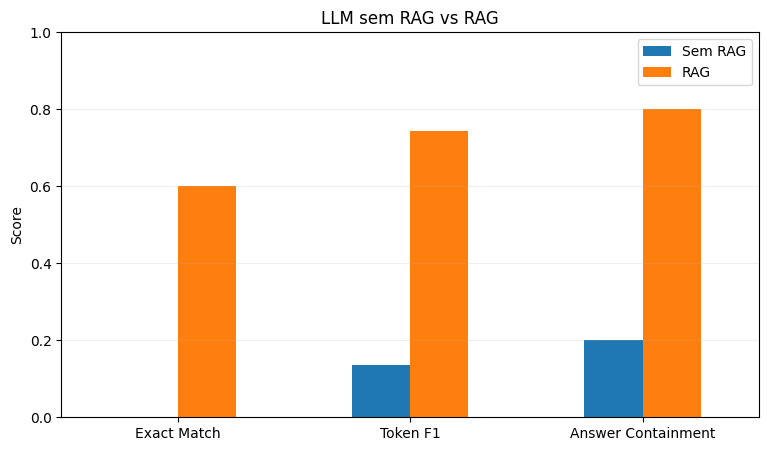

In [16]:
generation_summary = pd.DataFrame({
    "Sem RAG": {
        "Exact Match": generation_results["baseline_em"].mean(),
        "Token F1": generation_results["baseline_f1"].mean(),
        "Answer Containment": generation_results["baseline_containment"].mean(),
        "Latência média (s)": generation_results["baseline_latency_s"].mean(),
    },
    "RAG": {
        "Exact Match": generation_results["rag_em"].mean(),
        "Token F1": generation_results["rag_f1"].mean(),
        "Answer Containment": generation_results["rag_containment"].mean(),
        "Latência média (s)": generation_results["rag_latency_s"].mean(),
    },
}).T

display(generation_summary.round(4))

generation_summary[["Exact Match","Token F1","Answer Containment"]].T.plot(
    kind="bar",
    figsize=(9,5),
)
plt.title("LLM sem RAG vs RAG")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.2)
plt.show()


## 14. Decomposição de falhas

Um resultado ruim pode ter origens diferentes:

- **Retrieval failure:** a fonte correta não foi recuperada;
- **Context/chunk failure:** a fonte foi recuperada, mas o trecho com a resposta não chegou ao LLM;
- **Generation failure:** havia evidência no contexto, mas a resposta continuou ruim.


In [17]:
def failure_type(row):
    if row["rag_f1"] >= 0.8:
        return "Resposta forte"
    if row["retrieval_hit"] == 0:
        return "Retrieval failure"
    if row["answer_supported"] == 0:
        return "Context/chunk failure"
    return "Generation failure"

generation_results["failure_type"] = generation_results.apply(
    failure_type,
    axis=1,
)

display(generation_results["failure_type"].value_counts().to_frame("Quantidade"))

display(
    generation_results[
        ["question","reference_answer","rag_answer","retrieval_hit",
         "answer_supported","rag_f1","failure_type"]
    ].sort_values("rag_f1")
)


,Quantidade
failure_type,
Resposta forte,9
Generation failure,6


,question,reference_answer,rag_answer,retrieval_hit,answer_supported,rag_f1,failure_type
8,What is another term for the pivot mounting?,trunnion,Pivot mounting,1,1,0.000000,Generation failure
12,When does Doctor Who transition to a new body?,after sustaining an injury,The Doctor transitions to a new body during re...,1,1,0.111111,Generation failure
2,What do some believe the Treaty of Versailles ...,Adolf Hitler's rise to power,The Treaty of Versailles and the prohibition o...,1,1,0.357143,Generation failure
14,What animals does the Vistula river's ecosyste...,"otter, beaver and hundreds of bird species","Otters, beavers, and numerous bird species.",1,1,0.461538,Generation failure
13,How is packet mode communication implemented,with or without intermediate forwarding nodes,Packet mode communication may be implemented w...,1,1,0.545455,Generation failure
4,How many universities does Newcastle have?,two,Two universities,1,1,0.666667,Generation failure
1,Who made experimental measurements on a model ...,Watt,Watt,1,1,1.000000,Resposta forte
0,What shape are pyrenoids?,roughly spherical,Roughly spherical,1,1,1.000000,Resposta forte
7,Who was assigned to design a second master plan?,Eero Saarinen,Eero Saarinen,1,1,1.000000,Resposta forte
6,What is the term of office for each house member?,four years,Four years,1,1,1.000000,Resposta forte


## 15. Inspeção do pior caso


In [18]:
worst = generation_results.sort_values("rag_f1").iloc[0]
worst_retrieval = retrieve(worst["question"], TOP_K)

print("PERGUNTA")
print(worst["question"])

print("\nREFERÊNCIA")
print(worst["reference_answer"])

print("\nRAG")
print(worst["rag_answer"])

print("\nTIPO DE FALHA")
print(worst["failure_type"])

display(worst_retrieval)


PERGUNTA
What is another term for the pivot mounting?

REFERÊNCIA
trunnion

RAG
Pivot mounting

TIPO DE FALHA
Generation failure


,rank,score,chunk_id,source_id,title,text
0,1,0.391605,chunk_00105,doc_0069,Geology,"are facing downward, the structure is called a..."
1,2,0.310052,chunk_00048,doc_0032,Steam_engine,An oscillating cylinder steam engine is a vari...
2,3,0.289479,chunk_00205,doc_0142,Construction,"to end. This is designated as a ""design build""..."
3,4,0.248427,chunk_00274,doc_0188,Steam_engine,"to overlap the port on the admission side, wit..."


## 16. Interface final do pipeline


In [19]:
def rag_query(question, top_k=TOP_K):
    raw, retrieved, _ = answer_with_rag(question, top_k)
    answer, sources = parse_rag_response(raw)

    return {
        "question": question,
        "answer": answer,
        "sources": sources,
        "retrieved_chunks": retrieved,
    }

demo = rag_query(example["question"])
print("Resposta:", demo["answer"])
print("Fontes:", demo["sources"])


Resposta: I don't know based on the provided context.
Fontes: doc_0248, doc_0256, doc_0268, doc_0172


## 17. Conclusão

A conclusão abaixo usa apenas os resultados obtidos nesta execução.


In [20]:
from IPython.display import Markdown, display

hit1 = retrieval_summary["Hit@1"]
hitk = retrieval_summary[f"Hit@{TOP_K}"]
mrr = retrieval_summary["MRR"]

baseline_f1 = generation_summary.loc["Sem RAG","Token F1"]
rag_f1 = generation_summary.loc["RAG","Token F1"]

baseline_cont = generation_summary.loc["Sem RAG","Answer Containment"]
rag_cont = generation_summary.loc["RAG","Answer Containment"]

baseline_latency = generation_summary.loc["Sem RAG","Latência média (s)"]
rag_latency = generation_summary.loc["RAG","Latência média (s)"]

support_rate = generation_results["answer_supported"].mean()

conclusion = f'''
### Síntese dos resultados

#### Retrieval

- **Hit@1:** {hit1:.3f}
- **Hit@{TOP_K}:** {hitk:.3f}
- **MRR:** {mrr:.3f}
- **Resposta presente no contexto recuperado:** {support_rate:.3f}

#### Generation

**LLM sem RAG**
- Token F1: **{baseline_f1:.3f}**
- Answer Containment: **{baseline_cont:.3f}**

**RAG**
- Token F1: **{rag_f1:.3f}**
- Answer Containment: **{rag_cont:.3f}**

Diferença de Token F1: **{rag_f1 - baseline_f1:+.3f}**

#### Latência

- Sem RAG: **{baseline_latency:.2f} s**
- RAG: **{rag_latency:.2f} s**

### Interpretação

O experimento separa duas capacidades distintas:

1. encontrar informação relevante;
2. gerar uma resposta correta usando essa informação.

Um retriever forte não garante uma resposta final correta. Da mesma forma, um LLM mais capaz não corrige automaticamente um contexto inadequado.

RAG deve ser tratado como um pipeline mensurável:

**query → retrieval → context → generation → evaluation**

### Limitações

- corpus limitado a uma amostra do SQuAD;
- chunking fixo;
- apenas um embedding model;
- apenas um LLM;
- ausência de reranker;
- Exact Match e Token F1 penalizam paráfrases corretas;
- não há avaliação formal de faithfulness;
- a correção semântica das citações produzidas pelo LLM não é verificada;
- custo monetário e consumo energético não são medidos.

### Próximo estudo — Study 010: RAG Evaluation

O próximo notebook deverá transformar as principais decisões arquiteturais em variáveis experimentais:

- chunk size;
- overlap;
- Top-K;
- modelo de embeddings;
- reranking;
- context precision/recall;
- faithfulness;
- answer relevance;
- latência;
- custo.

A pergunta evolui de:

> “O RAG funciona?”

para:

> **“Quais escolhas de arquitetura produzem o melhor equilíbrio entre retrieval, grounding, qualidade, latência e custo?”**
'''

display(Markdown(conclusion))



### Síntese dos resultados

#### Retrieval

- **Hit@1:** 0.810
- **Hit@4:** 0.950
- **MRR:** 0.878
- **Resposta presente no contexto recuperado:** 1.000

#### Generation

**LLM sem RAG**
- Token F1: **0.136**
- Answer Containment: **0.200**

**RAG**
- Token F1: **0.743**
- Answer Containment: **0.800**

Diferença de Token F1: **+0.607**

#### Latência

- Sem RAG: **0.68 s**
- RAG: **2.12 s**

### Interpretação

O experimento separa duas capacidades distintas:

1. encontrar informação relevante;
2. gerar uma resposta correta usando essa informação.

Um retriever forte não garante uma resposta final correta. Da mesma forma, um LLM mais capaz não corrige automaticamente um contexto inadequado.

RAG deve ser tratado como um pipeline mensurável:

**query → retrieval → context → generation → evaluation**

### Limitações

- corpus limitado a uma amostra do SQuAD;
- chunking fixo;
- apenas um embedding model;
- apenas um LLM;
- ausência de reranker;
- Exact Match e Token F1 penalizam paráfrases corretas;
- não há avaliação formal de faithfulness;
- a correção semântica das citações produzidas pelo LLM não é verificada;
- custo monetário e consumo energético não são medidos.

### Próximo estudo — Study 010: RAG Evaluation

O próximo notebook deverá transformar as principais decisões arquiteturais em variáveis experimentais:

- chunk size;
- overlap;
- Top-K;
- modelo de embeddings;
- reranking;
- context precision/recall;
- faithfulness;
- answer relevance;
- latência;
- custo.

A pergunta evolui de:

> “O RAG funciona?”

para:

> **“Quais escolhas de arquitetura produzem o melhor equilíbrio entre retrieval, grounding, qualidade, latência e custo?”**


## 18. Próximos experimentos

### Retrieval
- diferentes embeddings;
- busca híbrida lexical + semântica;
- filtros por metadados;
- Top-K variável.

### Chunking
- diferentes tamanhos;
- diferentes overlaps;
- chunking semântico.

### Ranking
- CrossEncoder reranker;
- Maximum Marginal Relevance.

### Generation
- outros LLMs;
- prompts de abstention;
- geração estruturada.

### Evaluation
- Recall@K;
- nDCG;
- context precision;
- context recall;
- faithfulness;
- answer relevance;
- hallucination rate;
- LLM-as-a-Judge;
- avaliação humana.


## Referências

- SQuAD 1.1 — Stanford Question Answering Dataset;
- Sentence Transformers — semantic search;
- FAISS — similarity search;
- Qwen2.5-1.5B-Instruct;
- Hugging Face Transformers.

Para a publicação final, mantenha os outputs da execução no Colab e registre as versões das bibliotecas utilizadas.
